# Churn Validation Design and Recency Baseline

## Objective

Create a trustworthy time-based evaluation and establish the simple business rule that future machine-learning models must beat.

The baseline question is:

> Can we predict 90-day inactivity using only the number of days since the customer's last purchase?

No logistic regression or tree model is trained in this notebook.

## Why we cannot split rows randomly

The same customer can appear at several monthly snapshots, and every churn label uses the following 90 days. Random splitting could put a customer's nearby months into both training and testing, or allow a training answer to use activity that occurred after a validation prediction date.

We preserve the order of time and add a 90-day purge:

```text
Earlier snapshots        Purge / safety gap        Later validation snapshot
features + labels        no overlapping labels     genuinely later outcome
```

A training row is safe only when its entire future label period finishes on or before the later prediction date.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from customer_intelligence.churn import (
    baseline_metrics,
    final_temporal_holdout,
    purged_rolling_splits,
    recency_rule,
    tune_recency_threshold,
)
from customer_intelligence.segmentation.viz import apply_style, style_ax

apply_style()
sns.set_context("notebook")
BLUE = "#2A78D6"
ORANGE = "#EB6834"
GREEN = "#54A24B"
RED = "#E45756"

TRAINING_PATH = PROJECT_ROOT / "data" / "processed" / "churn_training_table.csv"

In [2]:
training_df = pd.read_csv(TRAINING_PATH, parse_dates=["SnapshotDate"])

print(f"Rows: {len(training_df):,}")
print(f"Customers: {training_df['Customer ID'].nunique():,}")
print(f"Snapshots: {training_df['SnapshotDate'].nunique()}")
print(f"Overall churn rate: {training_df['Churn'].mean():.1%}")

Rows: 47,821
Customers: 5,204
Snapshots: 16
Overall churn rate: 50.9%


## Rolling validation months

Four later months are used as repeated practice deployments. For each month, training uses all safely labelled earlier snapshots. Training expands as time moves forward.

September 2011 is not included in this process. It remains the final untouched test.

In [3]:
HORIZON_DAYS = 90
VALIDATION_DATES = pd.to_datetime([
    "2011-02-01",
    "2011-03-01",
    "2011-04-01",
    "2011-05-01",
])
FINAL_TEST_DATE = pd.Timestamp("2011-09-01")

folds = purged_rolling_splits(
    training_df,
    validation_dates=VALIDATION_DATES,
    horizon_days=HORIZON_DAYS,
)

fold_summary = pd.DataFrame([
    {
        "ValidationDate": fold.validation_date,
        "LatestSafeTrainingSnapshot": fold.latest_train_snapshot,
        "TrainingRows": len(fold.train_indices),
        "ValidationRows": len(fold.validation_indices),
    }
    for fold in folds
])
display(fold_summary.style.format({"TrainingRows": "{:,}", "ValidationRows": "{:,}"}))

,ValidationDate,LatestSafeTrainingSnapshot,TrainingRows,ValidationRows
0,2011-02-01 00:00:00,2010-11-01 00:00:00,"17,072","3,337"
1,2011-03-01 00:00:00,2010-12-01 00:00:00,"20,525","3,330"
2,2011-04-01 00:00:00,2011-01-01 00:00:00,"23,917","3,292"
3,2011-05-01 00:00:00,2011-01-01 00:00:00,"23,917","3,043"


### How to read the split table

If validation is 1 March, a December training snapshot is safe because its 90-day label ends exactly as March begins. A January training snapshot is unsafe because its future outcome extends into April and would cross the March validation date.

## Tune the simple Recency rule

The rule predicts churn when:

```text
Recency >= selected number of days
```

Thresholds are compared only on the four validation months. The winner maximizes mean Balanced Accuracy, which gives equal importance to recognising churners and returners.

In [4]:
CANDIDATE_THRESHOLDS = [15, 30, 45, 60, 75, 90, 105, 120, 135, 150]

best_threshold, threshold_summary, fold_results = tune_recency_threshold(
    training_df,
    folds=folds,
    thresholds=CANDIDATE_THRESHOLDS,
)

print(f"Selected Recency threshold: {best_threshold} days")
display(
    threshold_summary.style.format({
        column: "{:.3f}"
        for column in threshold_summary.columns
        if column != "ThresholdDays"
    })
)

Selected Recency threshold: 60 days


,ThresholdDays,MeanBalancedAccuracy,StdBalancedAccuracy,MeanPrecision,MeanRecall,MeanF1,MeanROCAUC,MeanPRAUC,MeanLiftAt20Pct
0,60,0.647,0.004,0.689,0.716,0.702,0.687,0.715,1.346
1,75,0.647,0.010,0.709,0.637,0.669,0.687,0.715,1.346
2,90,0.639,0.024,0.726,0.549,0.622,0.687,0.715,1.346
3,45,0.633,0.011,0.665,0.783,0.719,0.687,0.715,1.346
4,105,0.625,0.031,0.738,0.464,0.564,0.687,0.715,1.346
5,30,0.613,0.003,0.639,0.848,0.729,0.687,0.715,1.346
6,120,0.605,0.040,0.749,0.369,0.485,0.687,0.715,1.346
7,135,0.584,0.042,0.760,0.281,0.397,0.687,0.715,1.346
8,15,0.566,0.007,0.603,0.919,0.728,0.687,0.715,1.346
9,150,0.559,0.038,0.775,0.186,0.288,0.687,0.715,1.346


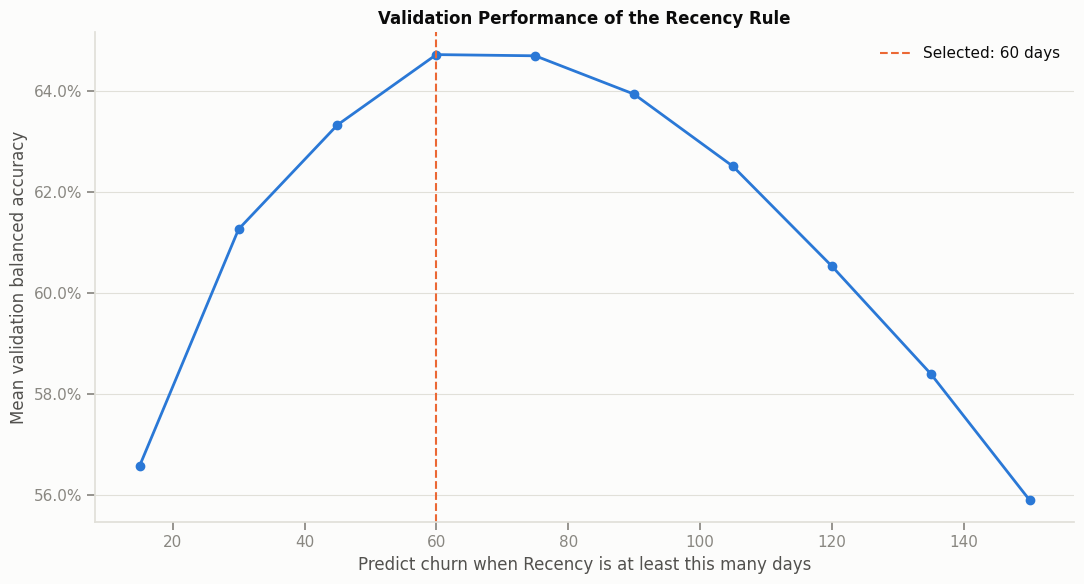

In [5]:
plot_thresholds = threshold_summary.sort_values("ThresholdDays")
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(
    plot_thresholds["ThresholdDays"],
    plot_thresholds["MeanBalancedAccuracy"],
    color=BLUE, marker="o", linewidth=2,
)
ax.axvline(
    best_threshold, color=ORANGE, linestyle="--",
    label=f"Selected: {best_threshold} days",
)
ax.set_title("Validation Performance of the Recency Rule", weight="bold")
ax.set_xlabel("Predict churn when Recency is at least this many days")
ax.set_ylabel("Mean validation balanced accuracy")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()

The 60- and 75-day rules perform similarly. Sixty days wins narrowly and is frozen before the final test is opened. A future business may choose a different threshold when campaign costs and contact capacity are known.

In [6]:
selected_fold_results = (
    fold_results[fold_results["ThresholdDays"] == best_threshold]
    .sort_values("ValidationDate")
)
display(
    selected_fold_results.style.format({
        "Precision": "{:.1%}",
        "Recall": "{:.1%}",
        "F1": "{:.1%}",
        "BalancedAccuracy": "{:.1%}",
        "ROCAUC": "{:.3f}",
        "PRAUC": "{:.3f}",
        "LiftAt20Pct": "{:.2f}×",
    })
)

,Fold,ValidationDate,ThresholdDays,Precision,Recall,F1,BalancedAccuracy,ROCAUC,PRAUC,LiftAt20Pct
3,1,2011-02-01 00:00:00,60,71.1%,76.0%,73.4%,64.4%,0.676,0.734,1.24×
13,2,2011-03-01 00:00:00,60,69.5%,75.8%,72.5%,65.2%,0.689,0.712,1.30×
23,3,2011-04-01 00:00:00,60,69.1%,69.4%,69.2%,64.8%,0.692,0.723,1.39×
33,4,2011-05-01 00:00:00,60,66.1%,65.2%,65.7%,64.3%,0.692,0.690,1.45×


## Open the final untouched test once

September 2011 represents the latest historical deployment. July and August are purged because their 90-day outcomes overlap the September prediction date.

The test is used only after the 60-day threshold has been selected.

In [7]:
development_idx, test_idx, purged_idx = final_temporal_holdout(
    training_df,
    test_date=FINAL_TEST_DATE,
    horizon_days=HORIZON_DAYS,
)

test_df = training_df.loc[test_idx].copy()
test_predictions = recency_rule(test_df["Recency"], best_threshold)
test_metrics = baseline_metrics(
    y_true=test_df["Churn"],
    predictions=test_predictions,
    risk_score=test_df["Recency"],
)

split_summary = pd.DataFrame({
    "Population": ["Development", "Purged safety months", "Final September test"],
    "Rows": [len(development_idx), len(purged_idx), len(test_idx)],
})
display(split_summary.style.format({"Rows": "{:,}"}))
display(pd.Series(test_metrics, name="Final test result").to_frame().style.format("{:.3f}"))

,Population,Rows
0,Development,"39,573"
1,Purged safety months,"5,482"
2,Final September test,"2,766"


,Final test result
Precision,0.515
Recall,0.614
F1,0.560
BalancedAccuracy,0.620
ROCAUC,0.657
PRAUC,0.543
LiftAt20Pct,1.551


## What the test metrics mean

- **Precision:** of customers flagged high-risk, how many actually churned?
- **Recall:** of customers who churned, how many did the rule find?
- **Balanced Accuracy:** average success on both churners and returners.
- **ROC-AUC / PR-AUC:** how well raw Recency ranks risk without fixing one threshold.
- **Lift at 20%:** how concentrated churn is among the 20% highest-Recency customers compared with contacting customers without ranking.

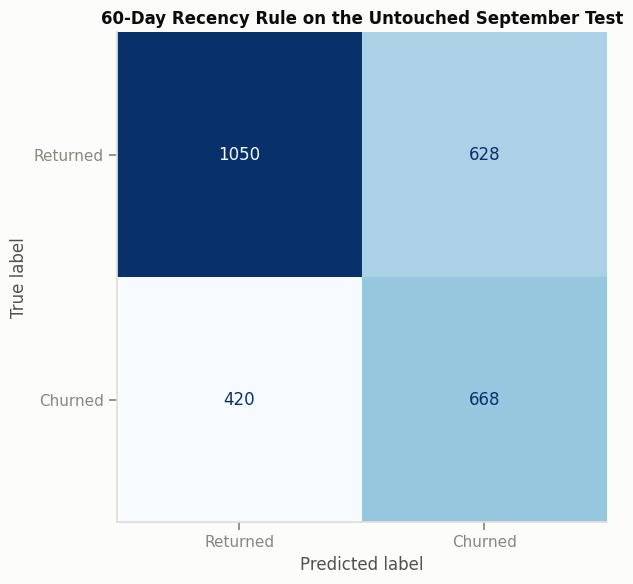

In [8]:
matrix = confusion_matrix(test_df["Churn"], test_predictions)
display_plot = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["Returned", "Churned"],
)
fig, ax = plt.subplots(figsize=(7, 6))
display_plot.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("60-Day Recency Rule on the Untouched September Test", weight="bold")
plt.tight_layout()
plt.show()

## Baseline conclusion

The selected rule is:

> Predict churn when the customer has been inactive for at least **60 days** at the snapshot.

Across rolling validation months, this rule achieved approximately **64.7% mean balanced accuracy**. On the untouched September test it achieved **61.4% recall**, **51.5% precision**, **62.0% balanced accuracy**, and **1.55× lift** in the highest-risk 20%.

The lower September performance is useful evidence of temporal/seasonal drift, not a reason to hide the result. Logistic regression and tree-based models must improve on this honest benchmark while remaining calibrated and useful under business contact limits.